In [1]:
import numpy as np
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
from scipy.signal import butter, filtfilt

local_path = "data/raw/mearec_test_10s.h5"
recording, sorting_true = se.read_mearec(local_path)
fs = recording.get_sampling_frequency()

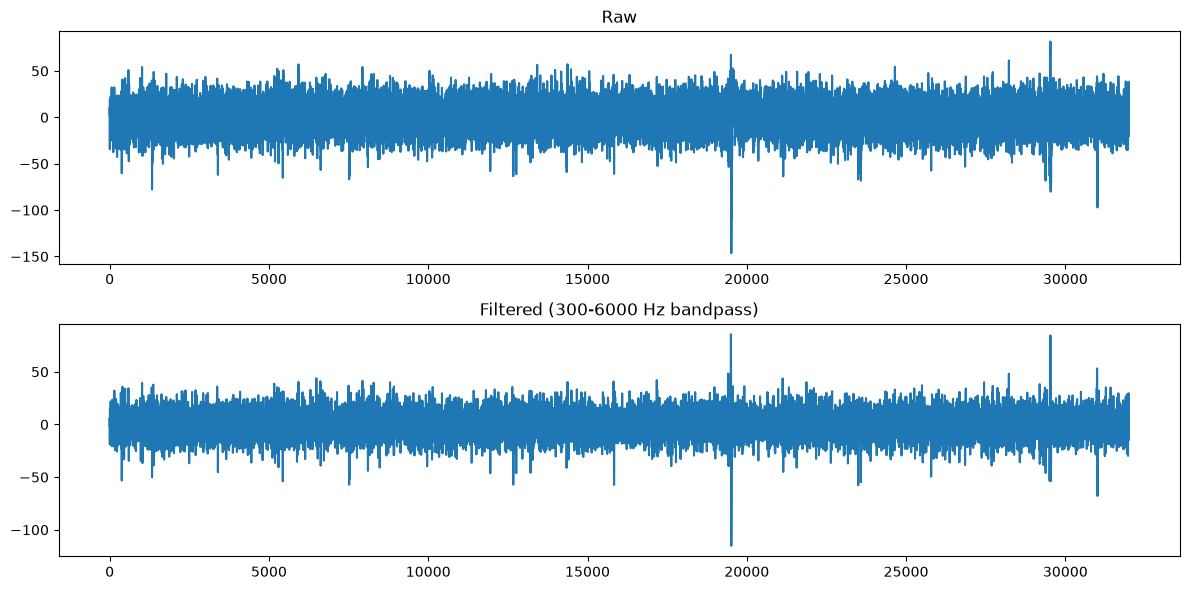

In [2]:
def bandpass_filter(signal, fs, low=300, high=6000):
    nyq = fs / 2
    b, a = butter(4, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, signal, axis=0)

raw_trace = recording.get_traces(channel_ids=[recording.channel_ids[0]]).flatten()
filtered_trace = bandpass_filter(raw_trace, fs)

plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(raw_trace[:int(fs)])
plt.title("Raw")
plt.subplot(2, 1, 2)
plt.plot(filtered_trace[:int(fs)])
plt.title("Filtered (300-6000 Hz bandpass)")
plt.tight_layout()
plt.show()

Detected 187 spikes


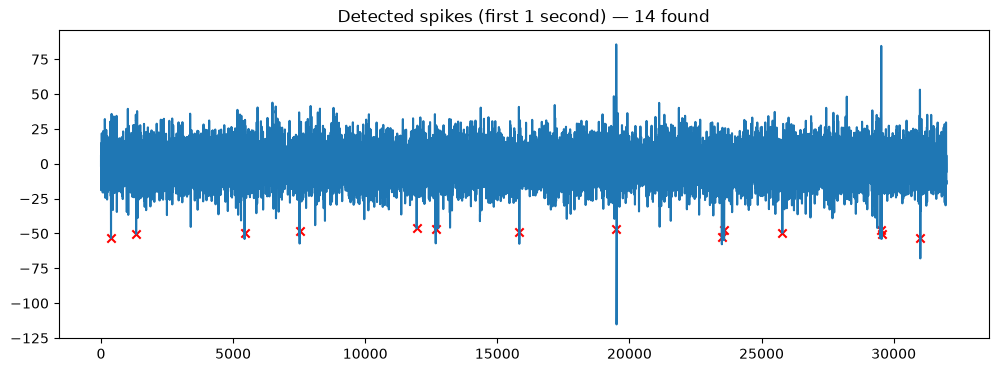

In [9]:
def detect_spikes(signal, fs, threshold_factor=4.0, refractory_ms=1.0):
    threshold = -threshold_factor * np.median(np.abs(signal) / 0.6745)
    refractory_samples = int((refractory_ms / 1000) * fs)

    below_threshold = signal < threshold
    crossings = np.where(below_threshold)[0]

    spike_times = []
    last_spike = -refractory_samples
    for idx in crossings:
        if idx - last_spike >= refractory_samples:
            spike_times.append(idx)
            last_spike = idx
    return np.array(spike_times)

detected_spike_times = detect_spikes(filtered_trace, fs)
print(f"Detected {len(detected_spike_times)} spikes")

plt.figure(figsize=(12, 4))
plt.plot(filtered_trace[:int(fs)])
spikes_in_window = detected_spike_times[detected_spike_times < fs]
plt.scatter(spikes_in_window, filtered_trace[spikes_in_window], color='red', marker='x')
plt.title(f"Detected spikes (first 1 second) — {len(spikes_in_window)} found")
plt.show()

In [10]:
np.save("data/raw/filtered_trace.npy", filtered_trace)
np.save("data/raw/detected_spike_times.npy", detected_spike_times)
print("saved")

saved
